# Steps for the exam
#### 1. Analyze the data and design appropriate transformations/preprocessing.  

#### 2. Train a model (training must happen on-the-fly when main.py is executed; it is possible, anyway, to run a grid search for parameter tuning and then use in the main.py file the desired model configuration).

#### 3. Predict labels for the provided test set.

#### 4. Save predictions to submission.csv (the file to be graded).

---

# clustering
Workflow:




In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, BisectingKMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_DS_1 = pd.read_csv('/Users/filippomontecchi/Desktop/Data Science & Machine Learning Lab/Lab/Dataset/LAB8/2D_gauss_clusters.txt')

df_DS_2 = pd.read_csv('/Users/filippomontecchi/Desktop/Data Science & Machine Learning Lab/Lab/Dataset/LAB8/chameleon_clusters.txt')

# df_DS_3 = pd.read_csv('/Users/filippomontecchi/Desktop/Data Science & Machine Learning Lab/Lab/Dataset/LAB8/T-newsgroups')

In [ ]:
df = df_DS_1
df

- this are 2D points --> we can draw them!

In [ ]:
# plot values

x = df['x'].values
y = df['y'].values
plt.figure(figsize=(8,8))
sns.scatterplot(x=x, y=y)
plt.title('plotting dataset distribution')
plt.show()




- we can see that the points form some quite clear clusters --> 15
- clusters are pretty high densed
- cluster are quite round-ish

> KMeans might behave nicely

In [ ]:
# KMeans expects a numeric feature matrix X of shape (n_samples, n_features)

df_DS_1 = pd.read_csv('/Users/filippomontecchi/Desktop/Data Science & Machine Learning Lab/Lab/Dataset/LAB8/2D_gauss_clusters.txt')
df = df_DS_1.copy()
data = df.values

kmeans = KMeans(n_clusters=15, init='k-means++', random_state=42)
kmeans.fit_predict(data)
centroids = kmeans.cluster_centers_
SSE = kmeans.inertia_
clusters = kmeans.labels_
print(SSE, centroids.shape, clusters.shape)
print(clusters)
print(np.unique(clusters))

print(f'SILHOUETTE SCORE: {silhouette_score(X=data, labels=clusters)}')


plt.figure(figsize=(8,8))
x = data[:, 0]
y = data[:, 1]
sns.scatterplot(x=x, y=y, hue=clusters)

x_centroids = centroids[:,0]
y_centroids = centroids[:,1]
sns.scatterplot(x=x_centroids, y=y_centroids, marker='X', s=80)
plt.title('KMeans clustering')
plt.legend()
plt.show()

- as you can see the clustering is decent but the silhouette score is quite low, very strict:

> The score quantifies how similar a point is to its own cluster (cohesion) compared to other clusters (separation). A higher average silhouette score across all points generally signifies a better clustering solution  

> Silhouette score ranges from -1 to +1, with values near +1 indicating strong, well-separated clusters (good clustering), values near 0 suggesting overlapping clusters or points on boundaries, and negative scores (close to -1) implying that points might be assigned to the wrong cluster (poor clustering)  

- try the BisectingKMeans

In [ ]:
df_DS_1 = pd.read_csv('/Users/filippomontecchi/Desktop/Data Science & Machine Learning Lab/Lab/Dataset/LAB8/2D_gauss_clusters.txt')
df = df_DS_1.copy()
data = df.values

bikmeans = BisectingKMeans(n_clusters=15, init='k-means++', random_state=42)
bikmeans.fit_predict(data)
centroids = bikmeans.cluster_centers_
SSE = bikmeans.inertia_
clusters = bikmeans.labels_
print()

print(SSE, centroids.shape, clusters.shape)
print(clusters)
print(np.unique(clusters))

print(f'SILHOUETTE SCORE: {silhouette_score(X=data, labels=clusters)}')

plt.figure(figsize=(8,8))
x = data[:, 0]
y = data[:, 1]
sns.scatterplot(x=x, y=y, hue=clusters)

x_centroids = centroids[:,0]
y_centroids = centroids[:,1]
sns.scatterplot(x=x_centroids, y=y_centroids, marker='X', s=80)
plt.title('KMeans clustering')
plt.legend()
plt.show()

#### GODDAMN THIS IS NICE :)

- try plotting n_neighbours and SSE and look for elbow

In [ ]:
data = df.values

SSEs = []
n_clusters = [8,10,15,20, 25, 30, 300]
for n in n_clusters:
    bikmeans = BisectingKMeans(n_clusters=n, random_state=42)
    bikmeans.fit_predict(data)
    SSE = bikmeans.inertia_
    SSEs.append(SSE)

plt.figure(figsize=(8,6))
plt.plot(n_clusters, SSEs)
plt.axvline(x=15, c='red', alpha = 0.3)
plt.axvline(x=30, c='green', alpha = 0.3)
plt.xlabel('number of clusters')
plt.ylabel('SSE score')
plt.title('Look for an elbow!')
plt.show()

#### It's weirdly happy with k = 30 too

- I'm curious let's try it

In [ ]:
df_DS_1 = pd.read_csv('/Users/filippomontecchi/Desktop/Data Science & Machine Learning Lab/Lab/Dataset/LAB8/2D_gauss_clusters.txt')
df = df_DS_1.copy()
data = df.values

bikmeans = BisectingKMeans(n_clusters=30, init='k-means++', random_state=42)
bikmeans.fit_predict(data)
centroids = bikmeans.cluster_centers_
SSE = bikmeans.inertia_
clusters = bikmeans.labels_
print(SSE, centroids.shape, clusters.shape)
print(clusters)
print(np.unique(clusters))

print(f'SILHOUETTE SCORE: {silhouette_score(X=data, labels=clusters)}')

plt.figure(figsize=(8,8))
x = data[:, 0]
y = data[:, 1]
sns.scatterplot(x=x, y=y, hue=clusters)

x_centroids = centroids[:,0]
y_centroids = centroids[:,1]
sns.scatterplot(x=x_centroids, y=y_centroids, marker='X', s=80)
plt.title('KMeans clustering')
plt.legend()
plt.show()

- try DBSCAN out of curiosity

In [ ]:
data = df.values

db = DBSCAN(n_jobs=-1)
db.fit_predict(data)

centroids = db.core_sample_indices_
clusters = db.labels_
print(centroids.shape, clusters.shape, np.unique(clusters))

plt.figure(figsize=(8,6))
x = data[:, 0]
y = data[:, 1]
sns.scatterplot(x=x, y=y, hue=clusters)
plt.show()

- It's just all noise --> bad tuning, do it the proper way

#### Plot method to figure out the correct value for eps
> - **SCALE FEATURES**

- compute the distance matrix from each point to each point --> NxN from-to matrix
- sort the distance matrix row-wise
- pick the K-th column = distance from each point to its K-th neighbour
- look for an elbow --> that is the value of eps
- the value of min_samples is K, try the plot again with a different number of min_samples

Euclidean distance:
for each point (x,y) compute:  
sqrt((x-x_i)^2 + (y-y_j)^2)

In [ ]:
data  = df.values
scaler = StandardScaler()
data = scaler.fit_transform(data)

distance_matrix = np.zeros(shape=(data.shape[0], data.shape[0]))
for fixed_point_idx in range(len(data)):
    fixed_point = data[fixed_point_idx, :]
    difference = data - fixed_point
    sqr_difference = difference**2
    sum_sqr_difference = np.sum(sqr_difference, axis=1)     # sum row wise
    distance = sum_sqr_difference**0.5          # distance from fixed point to all points
    distance_matrix[fixed_point_idx] = distance
    
# print(distance_matrix.shape)
# print(distance_matrix)

# don't subtract a point to itself --> drop first column
sorted_distance_matrix = np.sort(distance_matrix, axis=1)       # sort row wise
sorted_distance_matrix = sorted_distance_matrix[:, 1:]


# pick K-th neighbour, let's try a few K = min_samples = [2, 3, 5, 8, 10]
plt.figure(figsize=(12,12))
Ks = [2, 3, 5, 8, 10]
for plt_idx, k in enumerate(Ks):
    k_neighbour_distance = sorted_distance_matrix[:, k-1]       # -1 because I dropped one column
    sorted_k_neighbour_distance = np.sort(k_neighbour_distance)

    # plot it
    plt.subplot(3,2, plt_idx+1)
    plt.plot(sorted_k_neighbour_distance)
    plt.hlines(y=0.05, xmin=0, xmax=5000)
    plt.ylabel(f'distance to {k}-th neighbour')
    plt.title('find an elbow')

plt.tight_layout()
plt.show()



- try eps = 0.05 and min_samples = 5

In [ ]:
data = df.values

scaler = StandardScaler()
data = scaler.fit_transform(data)

db = DBSCAN(eps=0.07, min_samples=5, n_jobs=-1)
db.fit_predict(data)

centroids = db.core_sample_indices_
clusters = db.labels_

noise = []
for row, cluster in zip(data, clusters):
    if cluster == -1:
        noise.append(row)
noise = np.array(noise)

plt.figure(figsize=(8,6))
x = data[:, 0]
y = data[:, 1]
sns.scatterplot(x=x, y=y, hue=clusters)

x_noise = noise[:, 0]
y_noise = noise[:, 1]
sns.scatterplot(x=x_noise, y=y_noise, c='gray')
plt.show()

- meh, DBSCAN not really the best choice because of **VARYING DENSITY**

---

# Try other datasets

In [3]:
df_DS_2 = pd.read_csv('/Users/filippomontecchi/Desktop/Data Science & Machine Learning Lab/Lab/Dataset/LAB8/chameleon_clusters.txt')

df = df_DS_2.copy()
df

,x,y
0,68.601997,102.491997
1,454.665985,264.808990
2,101.283997,169.285995
3,372.614990,263.140991
4,300.989014,46.555000
...,...,...
7995,442.420990,303.721985
7996,495.451996,288.502991
7997,267.605011,141.725006
7998,238.358002,252.729996


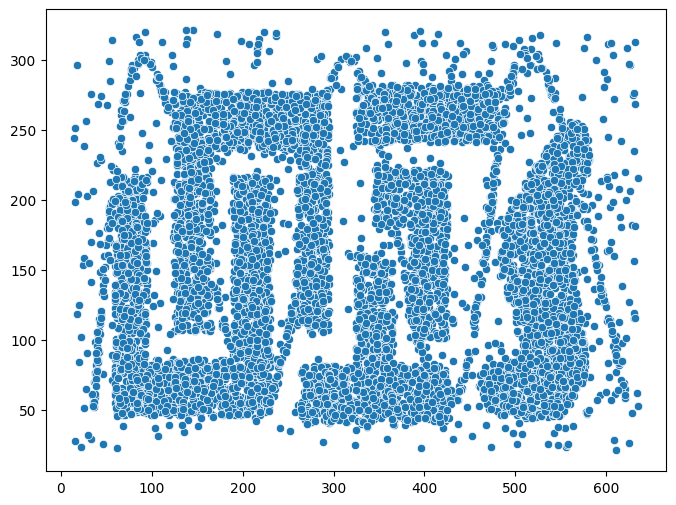

In [4]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['x'].values, y=df['y'].values)
plt.show()

- very dense regions
- weird non-globular shapes
- noise
- homogeneous density between clusters
- no high dimensionality

> this screams DBSCAN

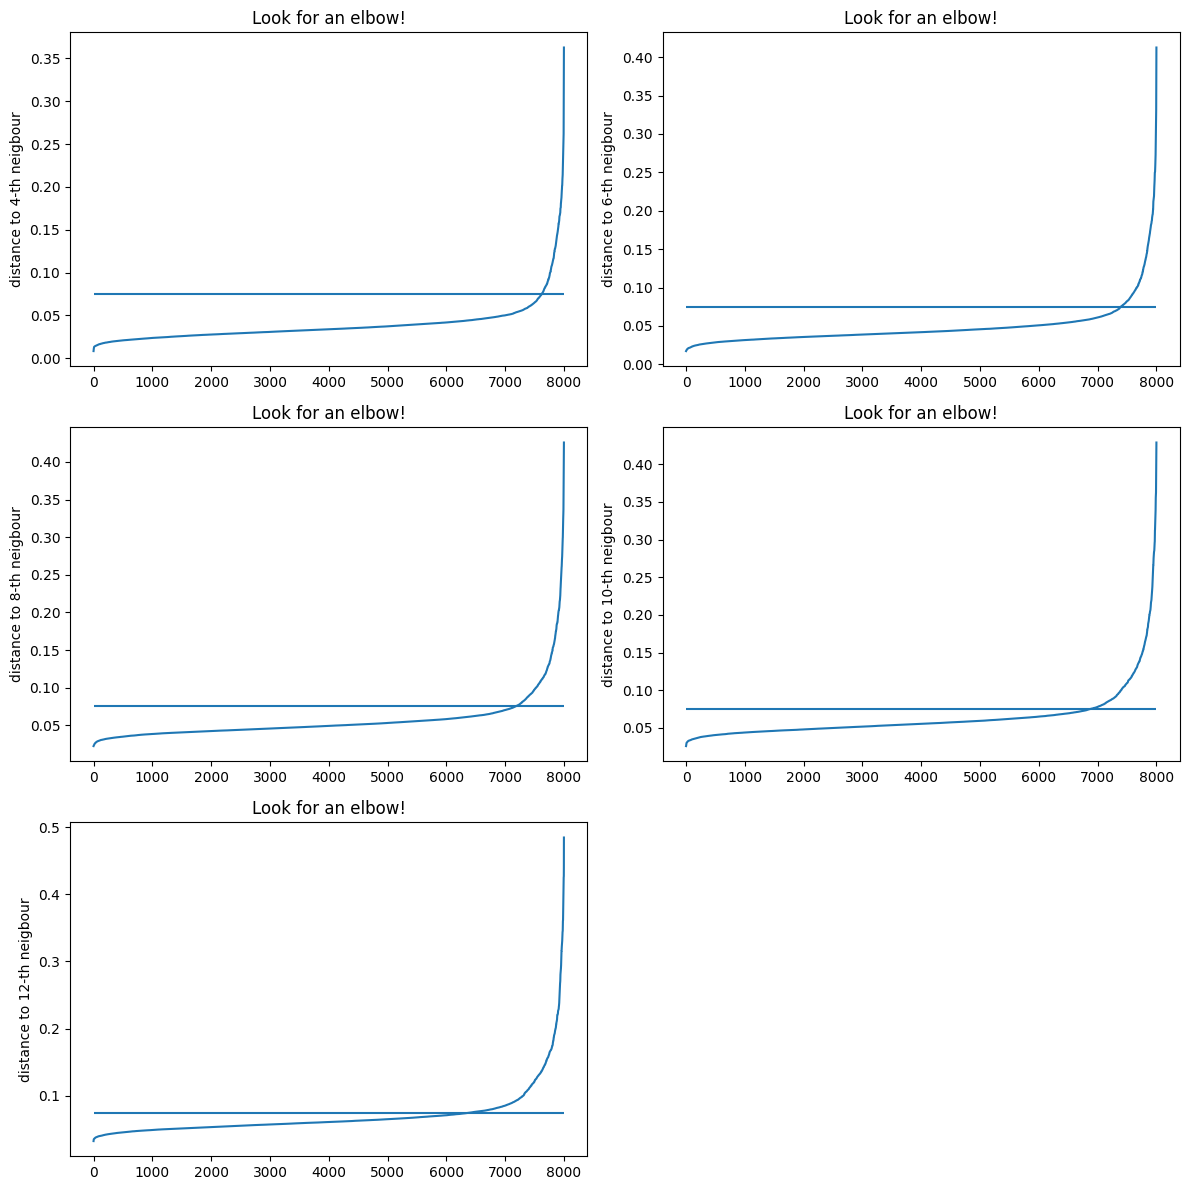

In [41]:
# scale
data = df.values
scaler = StandardScaler()
data = scaler .fit_transform(data)



# compute distance matrix 
distance_matrix = np.zeros(shape=(data.shape[0], data.shape[0]))
for fixed_idx in range(len(data)):
    fixed_point = data[fixed_idx]
    sqr_difference = (data - fixed_point)**2
    sum_sqr_difference = np.sum(sqr_difference, axis=1)
    distance = sum_sqr_difference**0.5
    distance_matrix[fixed_idx] = distance

# sort values row-wise, exclude first column and pick k = min_samples = [2,5,8,10,50]
sorted_distance_matrix = np.sort(distance_matrix, axis=1)
sorted_distance_matrix = sorted_distance_matrix[:, 1:]

Ks=[4, 6, 8, 10, 12]
plt.figure(figsize=(12,12))
for plt_idx, k in enumerate(Ks):
    k_neighbour_distance = sorted_distance_matrix[:, k-1]

    # sort it for the plot
    sorted_k_neighbour_distance = np.sort(k_neighbour_distance)

    # plot distance to k-th neighbour
    plt.subplot(3,2, plt_idx+1)
    plt.plot(sorted_k_neighbour_distance)
    plt.hlines(y=0.075, xmin=0, xmax=8000)
    plt.ylabel(f'distance to {k}-th neigbour')
    plt.title('Look for an elbow!')

plt.tight_layout()
plt.show()


- Try all combos:
    - n_samples = 4 and eps = 0.04 - 0.05
    - n_samples = 6 and eps = 0.05 - 0.55
    - n_samples = 8 and eps = 0.06 - 0.07
    - n_samples = 10 and eps = 0.07 - 0.08
    - n_samples = 12 and eps = 0.075 - 0.09

1. Pick a small set of min_samples candidates [4, 6, 8, 10, 12]  
2. For each one, plot the k-distance curve and pick an eps at the knee  
3. Then compare the clusterings.  

> “fits some noise too”:
- min_samples is too low  
**or**  
- eps is slightly too high

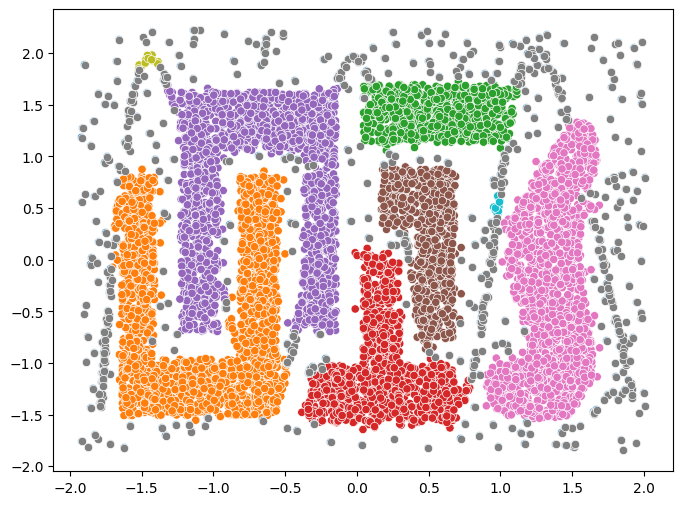

0.04748960087486223


In [47]:
data = df.values
scaler = StandardScaler()
data = scaler .fit_transform(data)

dbscan = DBSCAN(eps=0.070, min_samples=10, n_jobs=-1)
dbscan.fit_predict(data)

clusters = dbscan.labels_
core_point_idx = dbscan.core_sample_indices_
noise = []
for idx in range(len(clusters)):
    if clusters[idx] == -1:
        noise.append(data[idx,:])
noise = np.array(noise)


plt.figure(figsize=(8,6))
sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=clusters, palette="tab10", legend=False)
sns.scatterplot(x=noise[:, 0], y=noise[:,1], c='grey')
plt.show()

print(silhouette_score(data, clusters))

- eps=0.055, min_samples=5 --> ok with the main clusters but fits some noise too --> try to increase min_samples and change eps accordingly
- eps=0.070, min_samples=10 --> I'm ok with it

- try the bisecting K-means and we're ok

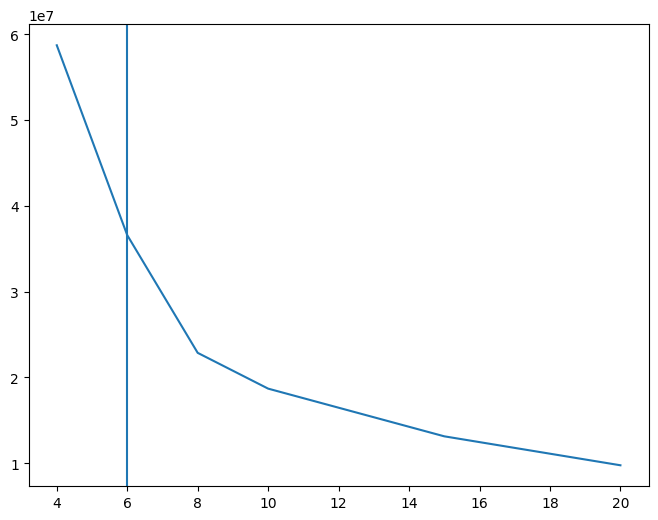

In [49]:
data = df.values

clusters = [4,6,8,10,15,20]
SSEs = []
for c in clusters:
    bikmeans = BisectingKMeans(n_clusters=c, random_state=42)
    bikmeans.fit_predict(data)
    SSEs.append(bikmeans.inertia_)


plt.figure(figsize=(8,6))
plt.plot(clusters, SSEs)
plt.axvline(x=6)
plt.show()

- I would try with k = 8 or 10

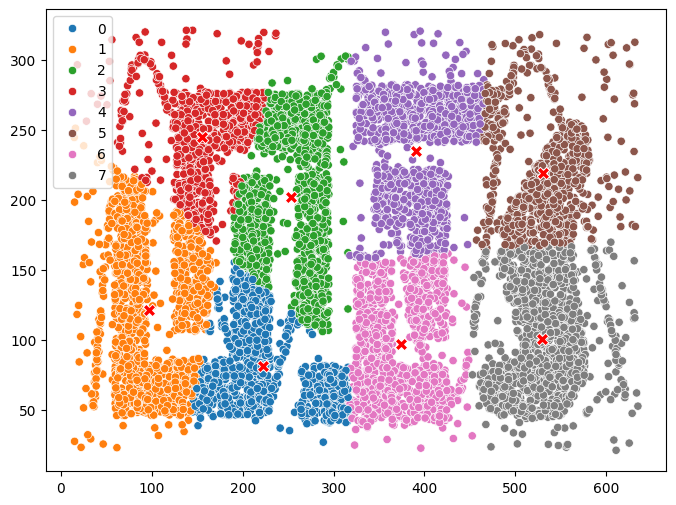

0.384912621336279


In [52]:
data = df.values
bikmeans = BisectingKMeans(n_clusters=8, random_state=42)
bikmeans.fit_predict(data)
centroids = bikmeans.cluster_centers_
clusters = bikmeans.labels_

plt.figure(figsize=(8,6))
sns.scatterplot(x=data[:,0], y=data[:,1], hue=clusters, palette='tab10')
sns.scatterplot(x=centroids[:,0], y=centroids[:,1], c='red', s=80, marker='X')
plt.show()

print(silhouette_score(data, clusters))

- as you can see the silhouette score is a liar
- not the right clustering, shapes are still globular-ish while they should have weird shapes and follow density

---

---

> # anomaly detection core coding